In [ ]:
!sudo apt-get install -y fonts-nanum* | tail -n 1
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 4.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no suc

In [ ]:
# 필요 라이브러리 설치

!pip install torchviz | tail -n 1
!pip install torchinfo | tail -n 1

런타임 다시 시작

In [ ]:
# 라이브러리 임포트

%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# 폰트 관련 용도
import matplotlib.font_manager as fm

# 나눔 고딕 폰트의 경로 명시
path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=path, size=10).get_name()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchviz import make_dot

In [ ]:
# 기본 폰트 설정
plt.rcParams['font.family'] = font_name

# 기본 폰트 사이즈 변경
plt.rcParams['font.size'] = 14

# 기본 그래프 사이즈 변경
plt.rcParams['figure.figsize'] = (6,6)

# 기본 그리드 표시
# 필요에 따라 설정할 때는, plt.grid()
plt.rcParams['axes.grid'] = True

# 마이너스 기호 정상 출력
plt.rcParams['axes.unicode_minus'] = False

# 넘파이 부동소수점 자릿수 표시
np.set_printoptions(suppress=True, precision=4)

In [ ]:
# device 설정 코드
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

### 보스턴 데이터셋 사용 실습

In [ ]:
# 학습용 데이터셋 준비

# '보스턴 데이터셋'은 현재 사이킷런 라이브러리에서 가져올 수 있지만,
# 사이킷런에서 앞으로 이 데이터를 사용할 수 없기 때문에 웹 url에서 직접 수집

data_url = "http://lib.stat.cmu.edu/datasets/boston"
# 원본 데이터
raw_df = pd.read_csv(data_url, sep="\s+",
                     skiprows=22, header=None)

# print(raw_df)
x_org = np.hstack([raw_df.values[::2, :],
                   raw_df.values[1::2, :2]])
# print(x_org)
yt = raw_df.values[1::2, 2]
# print(yt)
feature_names = np.array(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX',
                          'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO','B', 'LSTAT'])

# 결과 확인
print('원본 데이터', x_org.shape, yt.shape)
print('항목명: ', feature_names)

<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2562/2478662075.py:8: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+",


원본 데이터 (506, 13) (506,)
항목명:  ['CRIM' 'ZN' 'INDUS' 'CHAS' 'NOX' 'RM' 'AGE' 'DIS' 'RAD' 'TAX' 'PTRATIO'
 'B' 'LSTAT']


In [ ]:
# 코드 5-18: 입력 데이터 추출

# 데이터 추출(RM 항목)
x = x_org[:, feature_names == 'RM'] # RM 특성만 선택하여 x에 저장
# print(x)
print('추출 후', x.shape)
print(x[:5, :])

# 정답 데이터 표시
print('정답 데이터')
print(yt[:5])

추출 후 (506, 1)
[[6.575]
 [6.421]
 [7.185]
 [6.998]
 [7.147]]
정답 데이터
[24.  21.6 34.7 33.4 36.2]


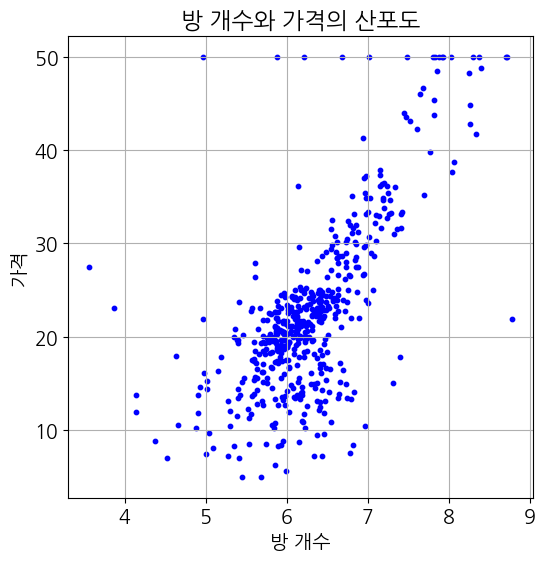

In [ ]:
# 코드 5-19: 산포도 출력

# 산포도 출력
plt.scatter(x, yt, s=10, c='b') # x축은 방 개수, y축은 가격
plt.xlabel('방 개수')
plt.ylabel('가격')
plt.title('방 개수와 가격의 산포도')
plt.grid(True)
plt.show()

In [ ]:
# 코드 5-20: 변수 정의

# 입력 차원수 (특성이 1개: RM)
n_input = x.shape[1]
# 출력 차원수 (예측할 값 1개: Price)
n_output = 1

print(f'입력 차원수: {n_input} 출력 차원수: {n_output}')

입력 차원수: 1 출력 차원수: 1


In [ ]:
# 코드 5-21: 머신러닝 모델(예측 모델)의 클래스 정의

# 머신러닝 모델(예측 모델)의 클래스 정의
class Net(nn.Module):
    def __init__(self, n_input, n_output): # 모델의 구조를 정의
        # 부모 클래스 nn.Module의 초기화 호출
        super().__init__()
        # 출력층 정의: 입력 차원에서 출력 차원으로 가는 선형 변환
        self.l1 = nn.Linear(n_input, n_output)

        # 초깃값을 모두 1로 설정
        nn.init.constant_(self.l1.weight, 1.0)
        nn.init.constant_(self.l1.bias, 1.0)

    # 예측 함수 정의
    def forward(self, x): # 데이터가 모델을 통과하는 흐름을 정의
        x1 = self.l1(x) # 선형 회귀 계산
        return x1

In [ ]:
# 코드 5-22: 인스턴스 생성

# 인스턴스 생성
# 1입력 1출력 선형 모델(모델에 device 설정해줌)
net = Net(n_input, n_output).to(device)

In [ ]:
# 코드 5-23: 모델 안의 파라미터 목록 표시

# 모델 안의 파라미터를 확인
# 모델 안의 변수를 가져오기 위해 named_parameters 함수를 사용함
# 첫번째 요소는 변수명, 두번째 요소가 변숫값
for parameter in net.named_parameters():
    print(f'변수명: {parameter[0]}')
    print(f'변숫값: {parameter[1].data}')

변수명: l1.weight
변숫값: tensor([[1.]])
변수명: l1.bias
변숫값: tensor([1.])


In [ ]:
# 코드 5-24: parameters 함수의 사용 예

# 파라미터의 리스트를 가져오기 위해 parameters 함수를 사용
for parameter in net.parameters():
    print(parameter)

Parameter containing:
tensor([[1.]], requires_grad=True)
Parameter containing:
tensor([1.], requires_grad=True)


In [ ]:
# 코드 5-25: 모델의 개요 표시 1

print(net)

Net(
  (l1): Linear(in_features=1, out_features=1, bias=True)
)


In [ ]:
# 코드 5-26: 모델의 개요 표시 2

# torchinfo 라이브러리를 사용하면 더 상세한 정보 확인 가능
from torchinfo import summary

summary(net, (1,))
# (1,) : 입력 텐서의 shape
# (batch_size, 1)
# 이미지 (MNIST) (1, 28, 28) CHW 1:채널(흑백)
# 컬러이미지 (3, 28, 28) 3: RGB

Layer (type:depth-idx)                   Output Shape              Param #
Net                                      [1]                       --
├─Linear: 1-1                            [1]                       2
Total params: 2
Trainable params: 2
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

In [ ]:
# 코드 5-27: 손실 함수와 최적화 함수 정의

# 손실 함수: 평균 제곱 오차(Mean Squared Error)
criterion = nn.MSELoss()

# 학습률
lr = 0.01

# 최적화 함수: 확률적 경사 하강법(Stochastic Gradient Descent)
# net.parameters() : 파라미터 조정(파라미터: 학습대상, w,b)
optimizer = optim.SGD(net.parameters(), lr=lr)

In [ ]:
# 코드 5-28: 입력값 x와 정답 yt의 텐서 변수화

# 입력값 x와 정답 yt의 텐서 변수화
inputs = torch.tensor(x).float().to(device)
labels = torch.tensor(yt).float()

# 차원 수 확인
print(inputs.shape)
print(labels.shape)

torch.Size([506, 1])
torch.Size([506])


In [ ]:
# 코드 5-29: 정답 labels를 (N, 1) 차원 행렬로 변형

# 손실 계산을 위해 labels를 (N, 1) 차원의 행렬로 변환
labels1 = labels.view((-1, 1)).to(device)

# 차원 수 확인
print(labels1.shape)

torch.Size([506, 1])


In [ ]:
# 코드 5-30: 예측 계산

# 예측 계산
outputs = net(inputs)
# print(outputs) # 모델의 예측값 >> y_hat(y_pred)

In [ ]:
# 코드 5-31: 손실 값 계산

# 손실 값 계산
loss = criterion(outputs, labels1)
# (예측값, 실제값) 비교 >> 손실 계산

print(loss)
# 손실 값 가져오기
print(f'{loss.item():.5f}')

tensor(308.4499, grad_fn=<MseLossBackward0>)
308.44986


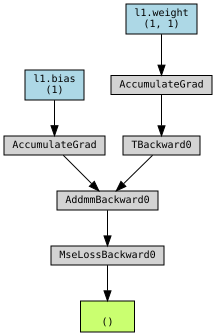

In [ ]:
# 코드 5-32: 계산 그래프 시각화

# 손실을 그래프로 나타내기
g = make_dot(loss, params=dict(net.named_parameters()))
display(g)

In [ ]:
# 코드 5-33: 경사 계산과 결과 확인

# 경사 계산
loss.backward()

# 경사 계산 결과를 확인
print(net.l1.weight.grad)
print(net.l1.bias.grad)

tensor([[-199.6421]])
tensor([-30.4963])


In [ ]:
# 코드 5-34: 파라미터 수정과 결과 확인

# 파라미터 수정
optimizer.step()

# 수정된 파라미터 확인
print(net.l1.weight)
print(net.l1.bias)

Parameter containing:
tensor([[2.9964]], requires_grad=True)
Parameter containing:
tensor([1.3050], requires_grad=True)


In [ ]:
# 코드 5-35: 경삿값 초기화

# 경삿값 초기화
optimizer.zero_grad()

# 경삿값이 0으로 초기화되었는지 확인
print(net.l1.weight.grad)
print(net.l1.bias.grad)

None
None


In [ ]:
# 코드 5-36: 초기화 처리

# 학습률
lr = 0.01

# 인스턴스 생성
net = Net(n_input, n_output).to(device)

# 손실함수
criterion = nn.MSELoss()
# 최적화 함수
# optimizer = optim.SGD(net.parameters(), lr=lr)
optimizer = optim.AdamW(net.parameters(), lr=lr)

# 반복 횟수
num_epochs = 5001

# 평가 결과 기록
history = np.zeros((0,2))

# 반복 계산 메인 루프
for epoch in range(num_epochs):
    # 경사값 초기화
    optimizer.zero_grad()
    # 예측 계산
    outputs = net(inputs)
    # 손실 계산
    loss = criterion(outputs, labels1)
    # 경사 계산
    loss.backward()
    # 파라미터 수정
    optimizer.step()
    # 1000회마다 경과 기록하고 출력
    if (epoch % 1000 == 0):
        history = np.vstack((history, np.array([epoch, loss.item()])))
        print(f"Epoch {epoch} loss: {loss.item():.5f}")

Epoch 0 loss: 308.44986
Epoch 1000 loss: 60.70185
Epoch 2000 loss: 59.39582
Epoch 3000 loss: 57.41397
Epoch 4000 loss: 54.79105
Epoch 5000 loss: 51.80618


In [ ]:
history

array([[   0.    ,  308.4499],
       [1000.    ,   60.7018],
       [2000.    ,   59.3958],
       [3000.    ,   57.414 ],
       [4000.    ,   54.791 ],
       [5000.    ,   51.8062]])

In [ ]:
print(f"초기 손실값: {history[0, 1]:.5f}")
print(f"최종 손실값: {history[-1, 1]:.5f}")

초기 손실값: 308.44986
최종 손실값: 51.80618


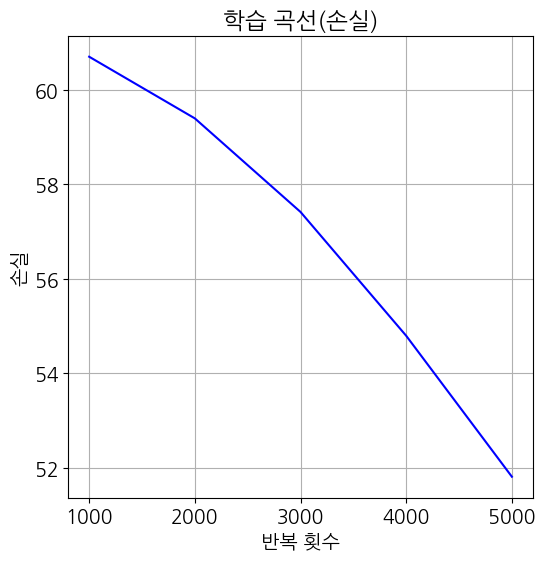

In [ ]:
# 코드 5-39 손실 값을 통한 학습 곡선 출력

# 학습 곡선 출력(손실)
# 가장 처음 요소는 제외
import matplotlib.pyplot as plt

plt.plot(history[1:,0], history[1:,1], 'b')
plt.xlabel('반복 횟수')
plt.ylabel('손실')
plt.title('학습 곡선(손실)')
plt.show()

In [ ]:
np.array((x.min(), x.max()))

array([3.561, 8.78 ])

In [ ]:
np.array((x.min(), x.max())).reshape(-1,1)

array([[3.561],
       [8.78 ]])

In [ ]:
np.array((x.min(), x.max()))

array([3.561, 8.78 ])

In [ ]:
# 회귀 직선 산출

# x의 최솟값, 최댓값
xse = np.array((x.min(), x.max())).reshape(-1,1)
Xse = torch.tensor(xse).float().to(device)

with torch.no_grad():
  Yse = net(Xse)

print(Yse.cpu().numpy())

[[ 9.074 ]
 [35.3761]]


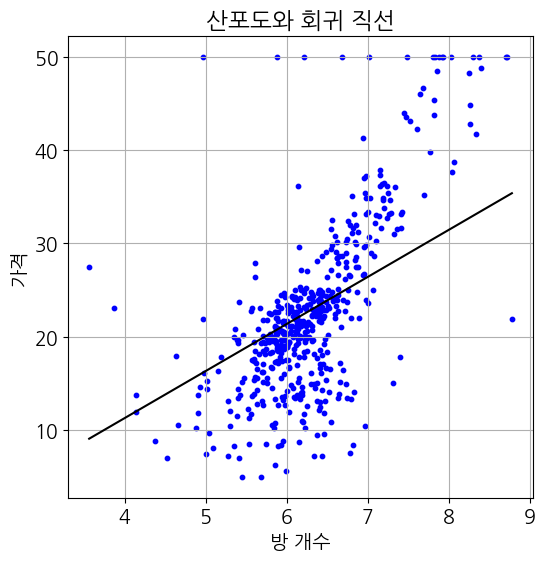

In [ ]:
# 코드 5-40 학습 데이터의 산포도와 회귀 직선 출력

# 산포도와 회귀 직선 출력
plt.scatter(x, yt, s=10, c='b')
plt.xlabel('방 개수')
plt.ylabel('가격')
plt.plot(Xse.cpu(), Yse.cpu(), c='k')
plt.title('산포도와 회귀 직선')
plt.show()